In [1]:
import matplotlib.pyplot as plt
import numpy as np


def load_mat_from_file(cur_file, step=0.0375):
    """
    step: 表示 相邻帧数据 步长
    """
    import h5py
    with h5py.File(cur_file, 'r') as f:
        pixels_array = f['d']['data'][:]
        # pos = f['d']['pos'][:] * step
        # ypos = f['d']['ypos'][:] * step
        # posend = f['d']['posend'][:] * step
        # yposend = f['d']['yposend'][:] * step
        
        # pos_array = np.vstack((pos, ypos, posend, yposend)).T
    return None, pixels_array

(60, 256, 121)


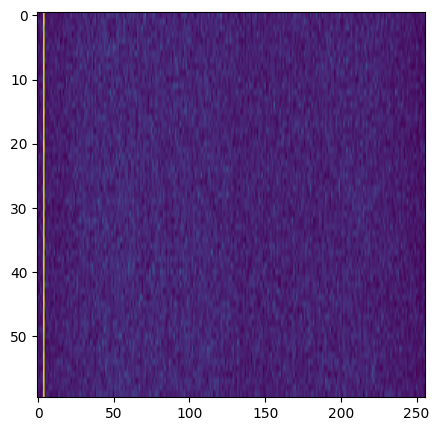

In [4]:
cor_filepath = r"D:\Acq_gui\Am_Spectrum\subset_1.mat"
cor_pos, cor_data = load_mat_from_file(cor_filepath)
print(cor_data.shape)

fig = plt.figure(figsize=(5, 5))
plt.imshow(cor_data.sum(axis=2), aspect='auto')
# sag_filepath = r"C:\Users\vplus\Documents\Projects\Acq_gui\ScanTask_600_100mmps_80kv_10ma_cali_10mspf_sid1000_cor.mat"

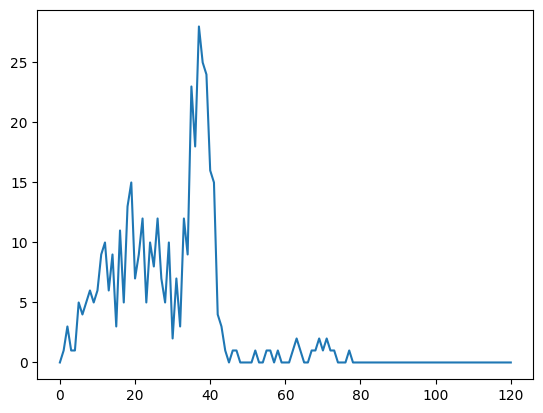

In [5]:
plt.plot(cor_data[:,128,:].sum(axis=0))

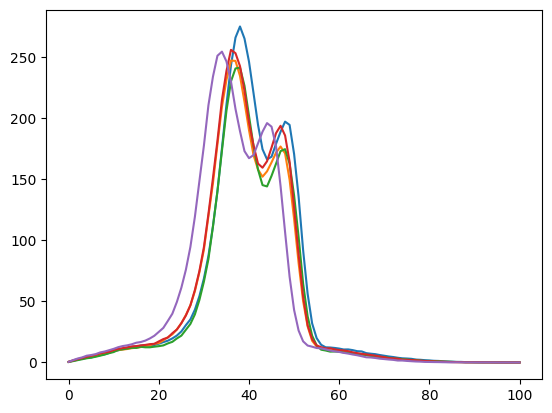

In [34]:
for cid in range(0,50,10):
    plt.plot(cor_data[0:200,cid,:].mean(axis=0))

In [6]:
import os
from tqdm import tqdm

base_dir = r"D:\Acq_gui\bei_acq"
all_pixel_arr = []
for filename in tqdm(os.listdir(base_dir)[:2000]):
    pos_arr, pix_arr = load_mat_from_file(os.path.join(base_dir, filename))
    all_pixel_arr.append(pix_arr)


100%|██████████| 2000/2000 [00:11<00:00, 179.23it/s]


In [7]:

all_pixel_arr2 = np.array(all_pixel_arr)

print(all_pixel_arr2.shape)

(2000, 50, 256, 101)


In [8]:

all_pixel_arr3 = np.vstack(all_pixel_arr)
print(all_pixel_arr3.shape)

(100000, 256, 101)


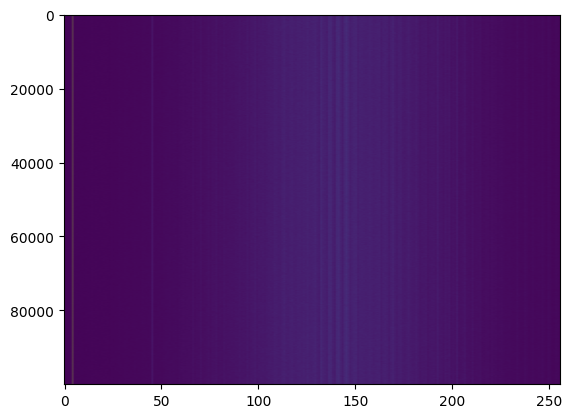

In [9]:

plt.imshow(all_pixel_arr3.sum(axis=2), aspect='auto')

In [10]:
tmp = all_pixel_arr3.sum(axis=0)[:, 10:]

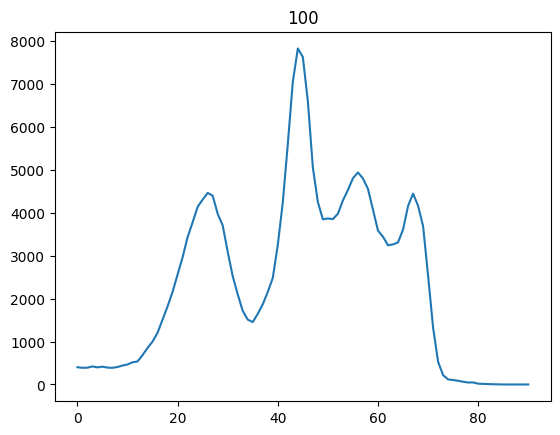

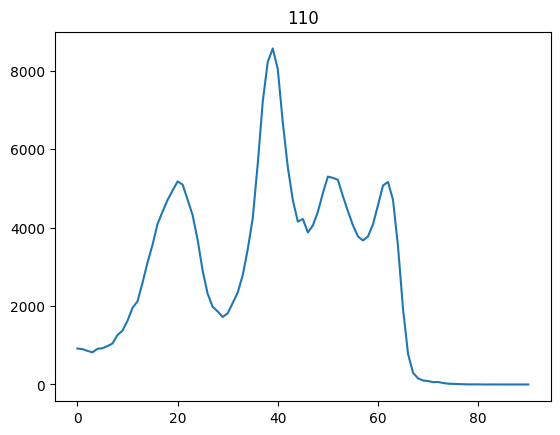

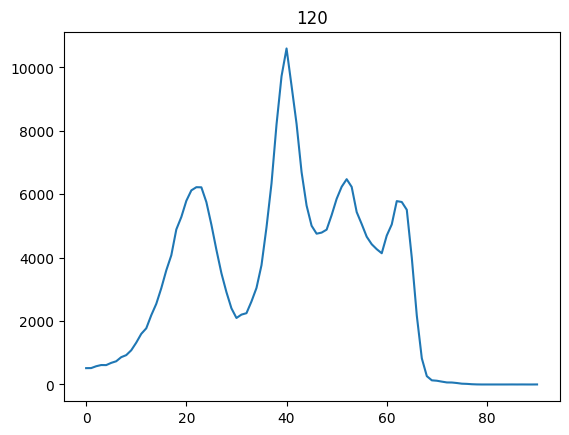

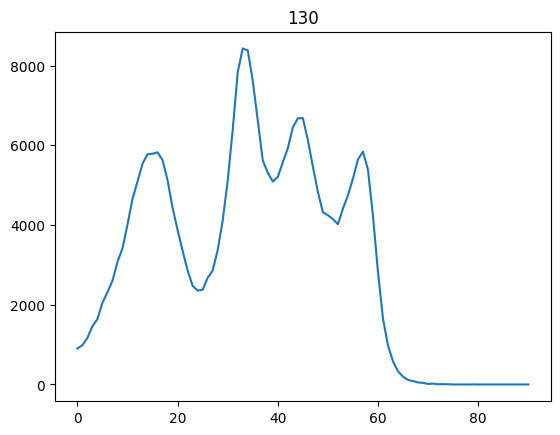

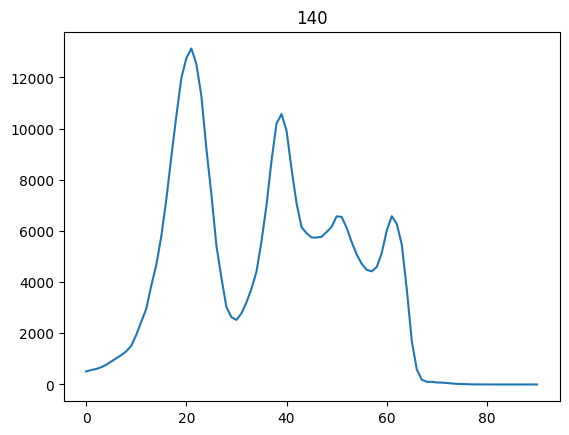

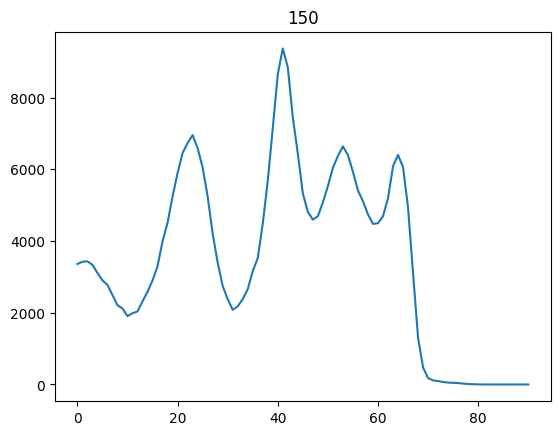

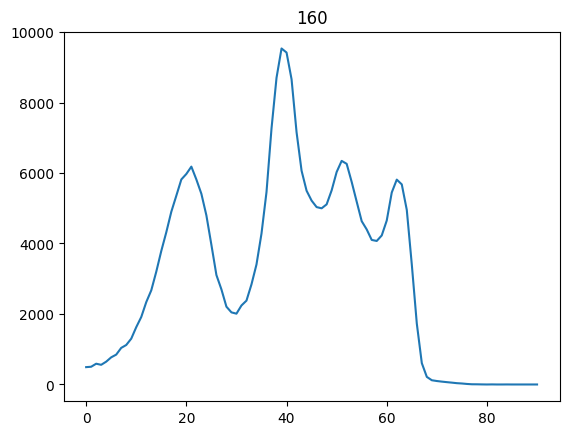

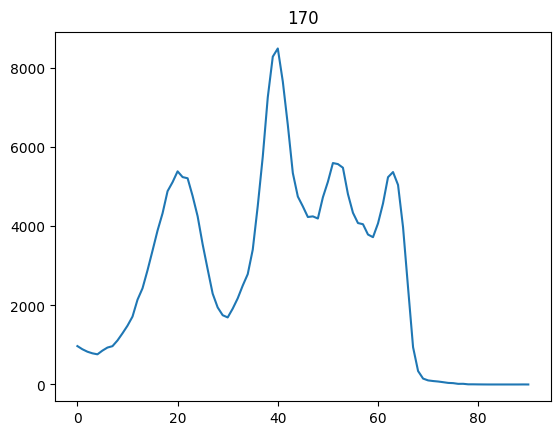

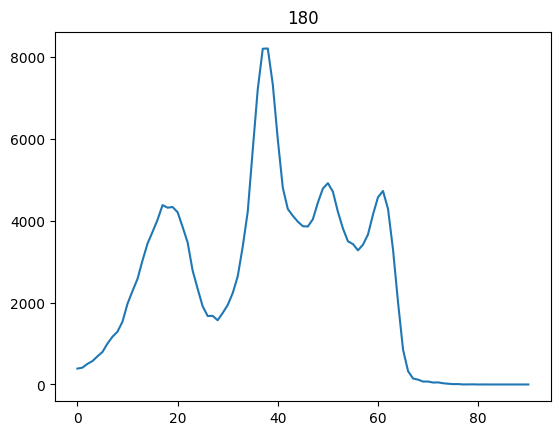

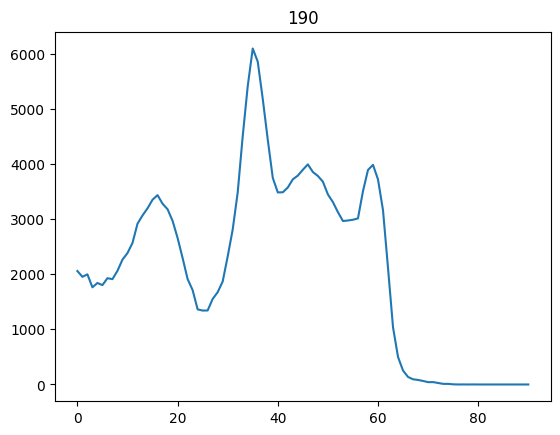

In [11]:
for i in range(100, 200, 10):
    _ = plt.plot(tmp[i].T)
    plt.title(i)
    plt.show()